<a href="https://colab.research.google.com/github/bmrribeiro/Analytical-Study-in-Education/blob/main/Analytical_Study_on_Education.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Theoretical Framework**

### **Dataset Information**

**Link:** https://www.kaggle.com/datasets/adilshamim8/personalized-learning-and-adaptive-education-dataset/data

This dataset contains information about the academic performance of secondary school students, collected from two Portuguese schools. It was originally presented by Cortez & Silva in the paper «Using Data Mining to Predict Secondary School Student Performance».

Data was collected through school reports and student questionnaires, covering demographic, social, and academic variables.
Features:

- Demographic data → sex, age, address, famsize, Pstatus

- Parental context → Medu, Fedu, Mjob, Fjob, guardian

- School-related → school, reason, traveltime, studytime, failures

- Support systems → schoolsup, famsup, paid, activities, nursery, higher, internet

- Lifestyle and social → romantic, freetime, goout, Dalc, Walc, health, absences

- Performance indicators → G1, G2, G3

- Target variable: G3

**Dataset variable description**

- school – Student’s school (GP = Gabriel Pereira, MS = Mousinho da Silveira)

- sex – Student’s gender (F = female, M = male)

- age – Student’s age (15–22 years)

- address – Home address type (U = urban, R = rural)

- famsize – Family size (LE3 = ≤3, GT3 = >3 members)

- Pstatus – Parent’s cohabitation status (T = together, A = apart)

- Medu – Mother’s education (0 = none, 1 = primary, 2 = 5–9th grade, 3 = secondary, 4 = higher)

- Fedu – Father’s education (0 = none, 1 = primary, 2 = 5–9th grade, 3 = secondary, 4 = higher)

- Mjob – Mother’s job (teacher, health, services, at_home, other)

- Fjob – Father’s job (teacher, health, services, at_home, other)

- reason – Reason for choosing school (home, reputation, course, other)

- guardian – Student’s guardian (mother, father, other)

- traveltime – Travel time to school (1 = <15 min, 2 = 15–30 min, 3 = 30–60 min, 4 = >1 hour)

- studytime – Weekly study time (1 = <2 hrs, 2 = 2–5 hrs, 3 = 5–10 hrs, 4 = >10 hrs)

- failures – Number of past class failures (n if 1 ≤ n < 3, else 4)

- schoolsup – Extra educational support (yes or no)

- famsup – Family educational support (yes or no)

- paid – Extra paid classes in the subject (yes or no)

- activities – Participation in extra-curricular activities (yes or no)

- nursery – Attended nursery school (yes or no)

- higher – Aspires to pursue higher education (yes or no)

- internet – Internet access at home (yes or no)

- romantic – In a romantic relationship (yes or no)

- famrel – Quality of family relationships (1 = very bad to 5 = excellent)

- freetime – Free time after school (1 = very low to 5 = very high)

- goout – Going out with friends (1 = very low to 5 = very high)

- Dalc – Workday alcohol consumption (1 = very low to 5 = very high)

- Walc – Weekend alcohol consumption (1 = very low to 5 = very high)

- health – Current health status (1 = very bad to 5 = very good)

- absences – Number of school absences (0–93)

- G1 – First period grade (0–20)

- G2 – Second period grade (0–20)

- G3 – Final grade (0–20, target variable)


**Reference:** Cortez, P., & Silva, A. Using Data Mining to Predict Secondary School Student Performance. Proceedings of the 5th Annual Future Business Technology Conference.


#**Objective**

**What:** The data in this dataset is real and allows us to investigate correlations between distinct variables and academic performance.

**Why:** I chose this dataset because it not only allows me to apply the knowledge acquired throughout my training, but its topic relates to my academic background, making it an area of personal interest.

**For what:** With this dataset, I aim to investigate the correlations between performance and the different student contexts. To that end, I will isolate the different variables in each context (see above) to analyse how these contexts affect student performance.

**How:** Formulation of hypotheses and definition of methods to address the proposed problems.


#**Procedures**

**Dataset exploration and treatment** — identify necessary data treatment steps: Are there missing values? Typos? Outliers?

**Correlation analysis** — heatmaps, Pearson and Spearman, Cramér's V;

**Hypothesis formulation** — problem definition;

**Data transformation/modelling** — grouping variables into categories, encoding, etc;

**Building predictive models** — KNN, Decision Tree, Random Forest, Regression; etc.

**Model evaluation** — accuracy, F1, etc.

**Notes**
G1 and G2 will have a very high correlation with G3, giving them high predictive power but low explanatory value.

Creation of a temporal target variable — Improvement — based on student performance over time: from G1 to G3.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Dataset and library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/student.csv', sep=';')

#**Dataset Overview**


In [ ]:
print(df.head())
print("\n Dataset shape: ", df.shape)
print("\n Dataset columns: ", df.columns)
print("\n Dataset info: ", df.info())
print("\n Dataset description:\n ", df.describe())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]

 Dataset shape:  (649, 33)

 Dataset columns:  Index(['school', 'sex', 'age', 'address'

In [ ]:
#Categorical variable inspection
cols = [
    'sex', 'address', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian',
    'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
    'internet', 'romantic'
]

for col in cols:
    print(f"Column: {col}")
    print(df[col].value_counts())


Column: sex
sex
F    383
M    266
Name: count, dtype: int64
Column: address
address
U    452
R    197
Name: count, dtype: int64
Column: Pstatus
Pstatus
T    569
A     80
Name: count, dtype: int64
Column: Mjob
Mjob
other       258
services    136
at_home     135
teacher      72
health       48
Name: count, dtype: int64
Column: Fjob
Fjob
other       367
services    181
at_home      42
teacher      36
health       23
Name: count, dtype: int64
Column: reason
reason
course        285
home          149
reputation    143
other          72
Name: count, dtype: int64
Column: guardian
guardian
mother    455
father    153
other      41
Name: count, dtype: int64
Column: schoolsup
schoolsup
no     581
yes     68
Name: count, dtype: int64
Column: famsup
famsup
yes    398
no     251
Name: count, dtype: int64
Column: paid
paid
no     610
yes     39
Name: count, dtype: int64
Column: activities
activities
no     334
yes    315
Name: count, dtype: int64
Column: nursery
nursery
yes    521
no     128
Name: 

#**Observations**

- 649 rows and 33 columns;

- No missing values;

- Dataset is well-structured with correct data types;

#**Numerical variables**

- Ages range from 15 to 22;

- Possible outlier in 'absences' — most values are around 6, with a maximum of 32 (visualise this variable);

- No grades above 19, minimum is 0. Most students score above 10. A grade improvement trend is visible from G1 to G3;

- Mothers tend to have higher education levels than fathers;

- Most students take less than 30 minutes to travel to school;

- Most students have no history of failing;

- Most students report good family relationships;

- Average of 3 for free time after school and going out with friends;

- Most students consume little alcohol on weekdays, with a slight increase on weekends;

- Average health score of 3.5;

#**Categorical variables**

- More female than male students;

- Most students are from urban areas;

- Most students have parents living together;

- Most students chose the school based on the course offered;

- Most students have their mother as guardian;

- Most students have extra educational support;

- More students have family support than not, though many still lack it;

- The vast majority pay for extra tutoring;

- Almost equal split between students who participate in extracurricular activities and those who don't;

- The vast majority aspire to higher education;

- Despite most students having internet access at home, many still don't (151);

- Most students are in a romantic relationship;

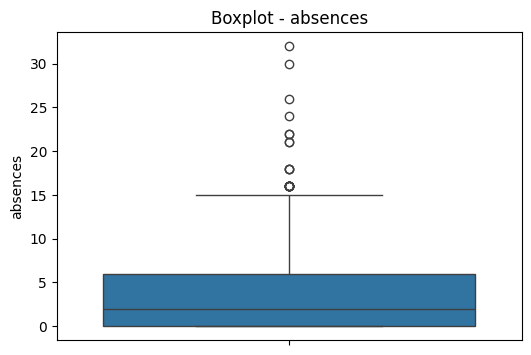

In [ ]:
#Boxplot of 'absences' to check for outliers
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['absences'])
plt.title('Boxplot - absences')
plt.show()

The presence of students with a high number of absences is entirely plausible in a school context. Removing or treating these outliers could skew the study, so it is preferable to measure the impact of absences on academic performance. If there were only one or two students with an unusually high number of absences, removing them might be justified as inconsistencies. However, that is not the case here, so the variable will be kept as is.

**Hypothesis to test:** Is there a correlation between a high number of absences and academic performance?




In [ ]:
#Correlation between absences and academic performance (G3)
df[['absences', 'G3']].corr(method='pearson')

,absences,G3
absences,1.000000,-0.091379
G3,-0.091379,1.000000


In [ ]:
#Count of students and their final grade with more than 15 absences
corr_abs_g3 = df.groupby('absences')['G3'].value_counts()
corr_abs_g3_filtered = corr_abs_g3.loc[corr_abs_g3.index.get_level_values('absences') > 15]
corr_abs_g3_filtered

absences  G3
16        10    4
          12    3
          8     2
          11    1
18        10    1
          13    1
          14    1
21        10    1
          13    1
22        6     1
          10    1
24        9     1
26        8     1
30        16    1
32        14    1
Name: count, dtype: int64

##**Hypothesis Response**

There is a weak negative correlation, meaning that as absences increase, G3 tends to decrease slightly, but the relationship is not strong. As shown in the table above, students with 30 or more absences still achieved grades above 14. Among students with more than 16 absences, only 5 had a final grade below 10. It can therefore be concluded that, while increased absences tend to lower the final grade, the correlation is quite weak.

---

##**Problem**

Which variables have the strongest correlation with G3, excluding G1 and G2?

---

#**Correlation methods: Pearson, Spearman and Cramér's V**

In [ ]:
#Evaluate the correlation of numerical variables with G3

#Select numerical variables excluding G1, G2 and G3
numeric_cols = df.select_dtypes(include=['int64']).columns.drop(['G1', 'G2', 'G3'])

#Pearson vs Spearman comparison
numeric_cols = numeric_cols.tolist()
pearson = df[numeric_cols + ['G3']].corr(method='pearson')['G3'].drop('G3')
spearman = df[numeric_cols + ['G3']].corr(method='spearman')['G3'].drop('G3')

comparison = pd.DataFrame({'Pearson': pearson, 'Spearman': spearman})
print(comparison.sort_values('Pearson', ascending=False))


             Pearson  Spearman
studytime   0.249789  0.274712
Medu        0.240151  0.283925
Fedu        0.211800  0.234633
famrel      0.063361  0.047755
goout      -0.087641 -0.104967
absences   -0.091379 -0.158510
health     -0.098851 -0.105672
age        -0.106505 -0.066277
freetime   -0.122705 -0.128375
traveltime -0.127173 -0.146948
Walc       -0.176619 -0.170895
Dalc       -0.204719 -0.208394
failures   -0.393316 -0.448360


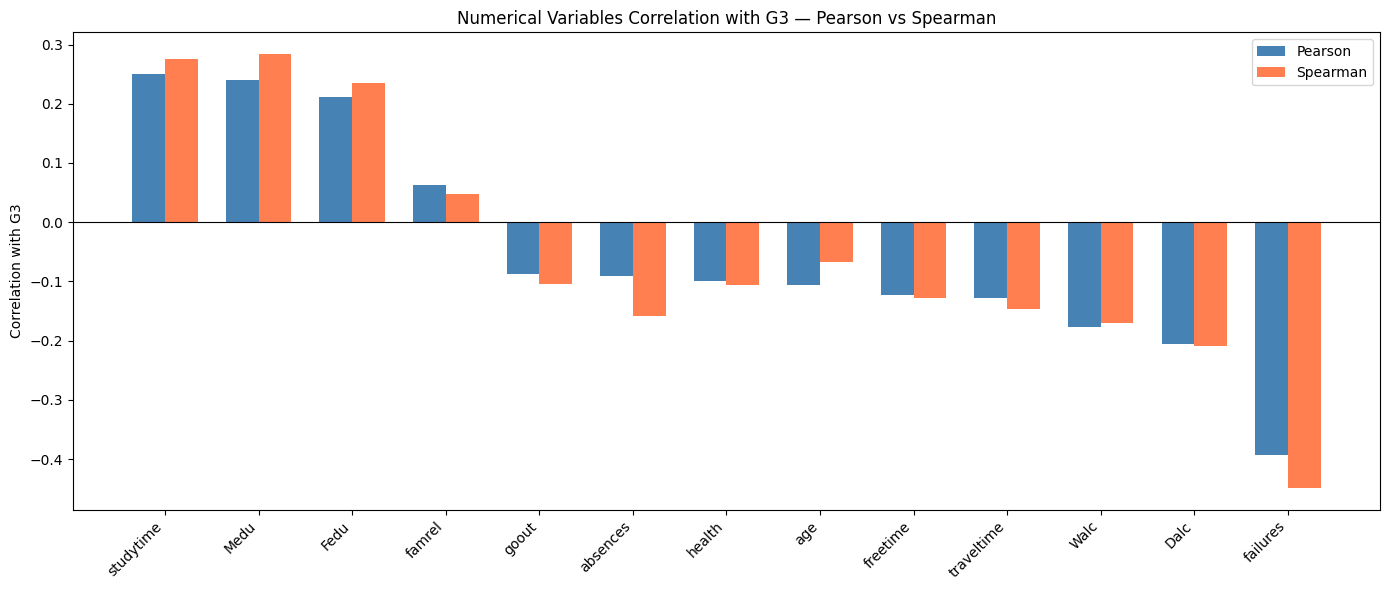

In [ ]:

comparison_sorted = comparison.sort_values('Pearson', ascending=False)

x = np.arange(len(comparison_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, comparison_sorted['Pearson'], width, label='Pearson', color='steelblue')
ax.bar(x + width/2, comparison_sorted['Spearman'], width, label='Spearman', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(comparison_sorted.index, rotation=45, ha='right')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Correlation with G3')
ax.set_title('Numerical Variables Correlation with G3 — Pearson vs Spearman')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Evaluation of the correlation of nominal variables with G3 using Cramér's V
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

object_vars = df.select_dtypes(include='object').columns.tolist()

for var in object_vars:
    v = cramers_v(df[var], df['G3'])
    print(f"{var}: {v:.3f}")

school: 0.377
sex: 0.184
address: 0.237
famsize: 0.133
Pstatus: 0.078
Mjob: 0.191
Fjob: 0.176
reason: 0.211
guardian: 0.156
schoolsup: 0.194
famsup: 0.173
paid: 0.147
activities: 0.183
nursery: 0.158
higher: 0.405
internet: 0.194
romantic: 0.162


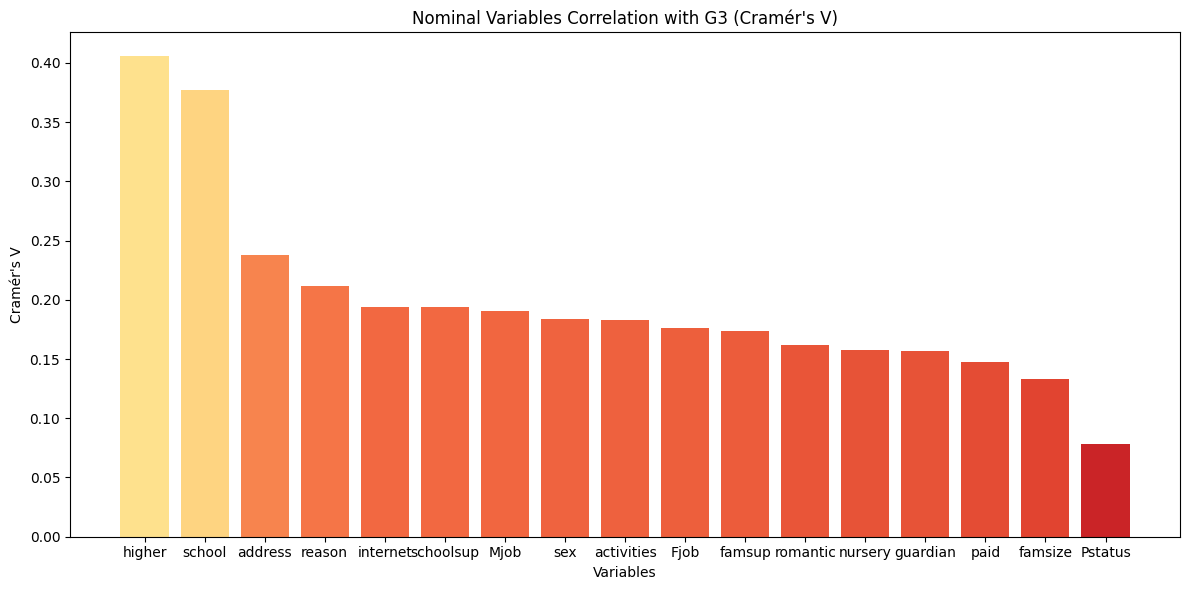

In [ ]:
#Cramér's V Visualization

import matplotlib.cm as cm

cramers_results = {}
for var in object_vars:
    cramers_results[var] = cramers_v(df[var], df['G3'])

cramers_series = pd.Series(cramers_results).sort_values(ascending=False)

colors = cm.RdYlGn(cramers_series.values)

plt.figure(figsize=(12, 6))
bars = plt.bar(cramers_series.index, cramers_series.values, color=colors)
plt.xlabel('Variables')
plt.ylabel("Cramér's V")
plt.title("Nominal Variables Correlation with G3 (Cramér's V)")
plt.tight_layout()
plt.show()

#**Resposta ao problema:**
Quais as variáveis com maior correlação com G3, sem contar com G1 e G2?

**Resposta:** Entre as variáveis númericas, encontramos maior relação em reprovações prévias (correlação negativa) - 'failures', nível de educação dos pais e tempo de estudo (correlação positiva).

Entre as variáveis nominais: aspiração ao ensino superior, escola e morada.

#**Problem Response**

Which variables have the strongest correlation with G3, excluding G1 and G2?

**Answer:** Among numerical variables, the strongest relationships are found in prior failures (negative correlation), parental education level, and study time (positive correlation). Among nominal variables: aspiration to higher education, school, and home address.

---

#**Hypotheses / Theories / Questions**

- It is plausible that the number of prior failures relates negatively to the final grade. However, while this shows the strongest correlation, there is little evidence of a direct causal relationship — it simply means that students with lower prior academic performance tend to maintain a lower performance level.

- It is plausible that parental education level and study time correlate with academic performance. Although their correlation coefficients are lower than that of 'failures', these variables present a stronger case for a causal relationship. Students with more educated parents tend to have more academic support and higher expectations. Study time appears to have the most direct cause-and-effect relationship with performance, even if its correlation is not very high.

- It is plausible that aspiration to higher education is strongly correlated with academic performance. **Question:** Is it related to study time?

- School as an influencing factor is outside the scope of this study, as we lack information about the schools themselves. However, it is believed to relate to the 'address' variable (urban vs rural). **Questions:** 1) Which school has better academic results? 2) Which area type has better results? 3) What is the address distribution across schools? 4) Could there be a relationship?

---

#**Observations and methodological notes**

- This dataset contains too few observations to draw generalisable conclusions about education in Portugal.

- This dataset does not capture potentially important factors, such as school facilities and resources.

- Cramér's V and Pearson/Spearman are not directly comparable in magnitude — they measure different phenomena.

- Correlation does not imply causation — each correlation must be interpreted within the context of the dataset.

In [ ]:
#Is 'higher' related to study time?
df.groupby('higher')['studytime'].mean()

,studytime
higher,
no,1.478261
yes,1.984483


In [ ]:
#What is the average final grade distribution by school
df.groupby('school')['G3'].agg(['mean', 'std', 'count']).round(2)

,mean,std,count
school,,,
GP,12.58,2.63,423
MS,10.65,3.83,226


In [ ]:
#What is the student's average grade distribution by address type?
df.groupby('address')['G3'].agg(['mean', 'std', 'count']).round(2)

,mean,std,count
address,,,
R,11.09,3.61,197
U,12.26,2.99,452


In [ ]:
#What is the student's distribution by address type across schools?
pd.crosstab(df['school'], df['address'])

address,R,U
school,,
GP,78,345
MS,119,107


#**Responses**

- Students who aspire to higher education study more hours than those who do not.

- Students from urban areas have a higher average grade than rural students, with less dispersion.

- The school with the highest proportion of urban students is also the one with the highest average grade and least dispersion. This suggests that student background may be a strong factor in each school's academic results.

---

#**Encoding Nominal Variables — Label Encoding and One-Hot Encoding**

**Data Preprocessing**

Binary nominal variables such as sex, school, or yes/no responses will be converted using label encoding.

The remaining nominal variables will use one-hot encoding.

In [ ]:
#Creation of a new dataset with encoded categorical variables
df1 = df.copy()

#Conversion of binary variables using label encoding/mapping
binary_vars = ['school', 'sex', 'address', 'famsize', 'Pstatus',
               'schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']

for col in binary_vars:
    df1[col] = df1[col].map({'yes': 1, 'no': 0,
                             'GP': 1, 'MS': 0,
                             'F': 1, 'M': 0,
                             'U': 1, 'R': 0,
                             'GT3': 1, 'LE3': 0,
                             'T': 1, 'A': 0})


In [ ]:
#Conversion of nominal variables using one-hot encoding
categorical_vars = ['Mjob', 'Fjob', 'reason', 'guardian']

df1 = pd.get_dummies(df1, columns=categorical_vars)
bool_cols = df1.select_dtypes(include=['bool']).columns
df1[bool_cols] = df1[bool_cols].astype(int)

#Columns visualization

print(df1.columns)
print(df1.shape)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid',
       'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services',
       'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other',
       'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home',
       'reason_other', 'reason_reputation', 'guardian_father',
       'guardian_mother', 'guardian_other'],
      dtype='object')
(649, 46)


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   school             649 non-null    int64
 1   sex                649 non-null    int64
 2   age                649 non-null    int64
 3   address            649 non-null    int64
 4   famsize            649 non-null    int64
 5   Pstatus            649 non-null    int64
 6   Medu               649 non-null    int64
 7   Fedu               649 non-null    int64
 8   traveltime         649 non-null    int64
 9   studytime          649 non-null    int64
 10  failures           649 non-null    int64
 11  schoolsup          649 non-null    int64
 12  famsup             649 non-null    int64
 13  paid               649 non-null    int64
 14  activities         649 non-null    int64
 15  nursery            649 non-null    int64
 16  higher             649 non-null    int64
 17  internet        

#**Creation of the 'Improvement' variable

 If G3 - G1 =
- Positive, then "Improved";
- 0, then "Unchanged";
- Negative, then "Declined.

In [ ]:
#Creating the variable "Improvement"
df1['Improvement'] = df1['G3'] - df1['G1']
df1['Improvement'] = df1['Improvement'].apply(lambda x: 'Improved' if x > 0 else ('Unchanged' if x == 0 else 'Declined'))

#Count and mean of grades in G1 and G3
df1.groupby('Improvement').agg(Count=('G1', 'count'), Mean_G1=('G1', 'mean'), Mean_G3=('G3', 'mean')).round(2)

,Count,Mean_G1,Mean_G3
Improvement,,,
Declined,120,11.47,9.47
Improved,344,10.95,12.60
Unchanged,185,12.19,12.19


#**Which variables contribute the most to the “improvement” factor?**

In df1, all variables are numeric except for “Improvement,” which we created above.

We will first use the Cramér’s V method (association);

Then, we will create a column with the numerical values of improvement over time (“Improvement”) and compute Pearson and Spearman correlations (correlation).

In [ ]:
#Creation of the "Improvement" numerical variable (to be usend in Pearson's and Spearman's correlation)
df1['Improvement_num'] = df1['G3'] - df1['G1']

#Columns to use
cols = [col for col in df1.columns if col not in ['G1', 'G2', 'G3', 'Improvement', 'Improvement_num']]

#Cramér's V
cramers_results = {}
for col in cols:
    cramers_results[col] = cramers_v(df1[col].astype(str), df1['Improvement'])

#Pearson e Spearman
pearson = df1[cols + ['Improvement_num']].corr(method='pearson')['Improvement_num'].drop('Improvement_num')
spearman = df1[cols + ['Improvement_num']].corr(method='spearman')['Improvement_num'].drop('Improvement_num')

#Comparison Table
comparison_evolucao = pd.DataFrame({'Pearson': pearson, 'Spearman': spearman})
comparison_evolucao['Cramér'] = pd.Series(cramers_results)
print(comparison_evolucao.sort_values('Pearson', ascending=False))

                    Pearson  Spearman    Cramér
Fjob_at_home       0.074731  0.103219  0.102676
age                0.073859  0.168685  0.153715
sex                0.072058  0.046938  0.044901
school             0.063228 -0.035828  0.054725
higher             0.063134 -0.000343  0.096933
address            0.060538 -0.009900  0.041450
absences           0.059728  0.056929  0.223662
internet           0.055215  0.031106  0.030067
studytime          0.049875  0.031193  0.097068
Fedu               0.047867 -0.000928  0.060646
famsup             0.047372  0.011501  0.052144
guardian_other     0.046008  0.080231  0.109587
famrel             0.038854  0.019982  0.088350
reason_reputation  0.035776  0.020739  0.048430
Medu               0.033381  0.002858  0.056239
reason_course      0.028198  0.021864  0.016561
Mjob_health        0.024812  0.001568  0.005288
Mjob_at_home       0.024129  0.027546  0.059648
Mjob_teacher       0.014834  0.025619  0.046047
Fjob_other         0.013592  0.022777  0

#**Answers**

**Question:** Are there associations between the dataset variables and student improvement?

The values are very low, indicating that none of the dataset variables has a relevant correlation or association with student improvement over the year.

Therefore, there is no strong basis for further analysis.

The fact that most variables in this dataset are static (i.e., they do not change over time) contributes to the inability to capture the dynamic nature of academic improvement.

This is a result that was expected *a priori*; however, the analysis was still carried out out of curiosity.

---


#**Predictive models: regression and classification**

**Data preprocessing for prediction**

The target variables will be “G3” and “Improvement.”

The performance indicator variables (G1, G2) will not be included as independent variables, as this would bias the results.

The goal is to understand how students’ life contexts influence performance.

---

#**Regression**

To predict “G3” (numerical target variable with values between 0–20)

In [ ]:
#Model and metrics imports

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#Definition of independent and target variables
x = df1.drop(columns=['G1', 'G2', 'G3', 'Improvement', 'Improvement_num'])
y = df1['G3']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

#Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


#Function to print metrics
def print_metrics(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"MAE:  {mae:.3f}")
    print(f"MSE:  {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}")
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}

results = []

#Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
results.append(print_metrics('Linear Regression', y_test, y_pred_lr))

#XGBoost
#Optimization of parameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(XGBRegressor(random_state=0), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(x_train, y_train)
print(f"\nBest XGBoost parameters: {grid_search.best_params_}")

xgb_reg = grid_search.best_estimator_
y_pred_xgb = xgb_reg.predict(x_test)
results.append(print_metrics('XGBoost', y_test, y_pred_xgb))

#Ridge
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(x_train_scaled, y_train)
print(f"\nBest Ridge alpha: {ridge_cv.alpha_:.3f}")

ridge = Ridge(alpha=ridge_cv.alpha_)
ridge.fit(x_train_scaled, y_train)
y_pred_ridge = ridge.predict(x_test_scaled)
results.append(print_metrics('Ridge', y_test, y_pred_ridge))

#Lasso
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(x_train_scaled, y_train)
print(f"Best Lasso alpha: {lasso_cv.alpha_:.3f}")

lasso = Lasso(alpha=lasso_cv.alpha_)
lasso.fit(x_train_scaled, y_train)
y_pred_lasso = lasso.predict(x_test_scaled)
results.append(print_metrics('Lasso', y_test, y_pred_lasso))

#SVR
svm_reg = SVR(C=1.0, kernel='rbf', gamma='scale')
svm_reg.fit(x_train_scaled, y_train)
y_pred_svr = svm_reg.predict(x_test_scaled)
results.append(print_metrics('SVR', y_test, y_pred_svr))

#Tabela comparativa
print("\nModel Comparison")
df_results = pd.DataFrame(results).set_index('Model').round(3)
print(df_results.sort_values('R²', ascending=False))



Linear Regression
MAE:  1.834
MSE:  6.995
RMSE: 2.645
R²:   0.225

Best XGBoost parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}

XGBoost
MAE:  1.898
MSE:  7.047
RMSE: 2.655
R²:   0.219

Best Ridge alpha: 215.443

Ridge
MAE:  1.798
MSE:  6.758
RMSE: 2.600
R²:   0.251
Best Lasso alpha: 0.115

Lasso
MAE:  1.826
MSE:  6.924
RMSE: 2.631
R²:   0.233

SVR
MAE:  1.835
MSE:  7.019
RMSE: 2.649
R²:   0.222

Model Comparison
                     MAE    MSE   RMSE     R²
Model                                        
Ridge              1.798  6.758  2.600  0.251
Lasso              1.826  6.924  2.631  0.233
Linear Regression  1.834  6.995  2.645  0.225
SVR                1.835  7.019  2.649  0.222
XGBoost            1.898  7.047  2.655  0.219


#**Conclusions**

The regression models show limited but expected performance.

The Ridge model delivers the best predictive results, with an R² of 0.25, meaning the model explains 25% of the variance in final grades. The models were deliberately built using only variables related to students’ life context, excluding G1 and G2, which would have significantly higher predictive power.

The goal was not to maximize accuracy, but rather to understand to what extent a student’s context explains their performance — and 25% is a meaningful answer to that question.


#**Classification**

To predict "Improvement" (Categorical target variable with 3 categories: "Improved", "Unchanged" and "Declined").

In [ ]:
#Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


#Metrics imports
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix
)

#Variable Definition
x = df1.drop(columns=['G1', 'G2', 'G3', 'Improvement', 'Improvement_num'])
y = df1['Improvement']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

#Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Printing function
def print_classification_report(name, y_test, y_pred):
    print(f"\n{name}")
    report = classification_report(y_test, y_pred)
    print(report)
    return {'Model': name, 'Report': report}

results = []

#Logistic Regression
param_grid_lr = {'C': [0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='f1_macro',)
grid_lr.fit(x_train_scaled, y_train)
lr = grid_lr.best_estimator_
y_pred_lr = lr.predict(x_test_scaled)
results.append(print_classification_report('Logistic Regression', y_test, y_pred_lr))

#SVM
param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='f1_macro',)
grid_svm.fit(x_train_scaled, y_train)
svm = grid_svm.best_estimator_
y_pred_svm = svm.predict(x_test_scaled)
results.append(print_classification_report('SVM', y_test, y_pred_svm))

#KNN
param_grid_knn = {'n_neighbors': list(range(1, 21))}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1_macro',)
grid_knn.fit(x_train_scaled, y_train)
knn = grid_knn.best_estimator_
y_pred_knn = knn.predict(x_test_scaled)
results.append(print_classification_report('KNN', y_test, y_pred_knn))

#Random Forest
n_estimators_values = list(range(1, 10))

max_depth_values = [None] + list(range(1, 16))

param_grid_rf = {
    'n_estimators': n_estimators_values,
    'max_depth': max_depth_values
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=0), param_grid_rf, cv=5, scoring='f1_macro',)
grid_rf.fit(x_train, y_train)
rf = grid_rf.best_estimator_
y_pred_rf = rf.predict(x_test)
results.append(print_classification_report('Random Forest', y_test, y_pred_rf))

#Gradient Boosting
param_grid_gb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=0), param_grid_gb, cv=5, scoring='f1_macro',)
grid_gb.fit(x_train, y_train)
gb = grid_gb.best_estimator_
y_pred_gb = gb.predict(x_test)
results.append(print_classification_report('Gradient Boosting', y_test, y_pred_gb))

#Naive Bayes
nb = GaussianNB()
nb.fit(x_train_scaled, y_train)
y_pred_nb = nb.predict(x_test_scaled)
results.append(print_classification_report('Naive Bayes', y_test, y_pred_nb))


Logistic Regression
              precision    recall  f1-score   support

    Declined       0.14      0.03      0.05        32
    Improved       0.55      0.85      0.67        85
   Unchanged       0.24      0.13      0.17        46

    accuracy                           0.48       163
   macro avg       0.31      0.34      0.30       163
weighted avg       0.38      0.48      0.41       163


SVM
              precision    recall  f1-score   support

    Declined       0.19      0.09      0.12        32
    Improved       0.51      0.67      0.58        85
   Unchanged       0.26      0.20      0.22        46

    accuracy                           0.42       163
   macro avg       0.32      0.32      0.31       163
weighted avg       0.37      0.42      0.39       163


KNN
              precision    recall  f1-score   support

    Declined       0.33      0.28      0.31        32
    Improved       0.53      0.60      0.56        85
   Unchanged       0.28      0.24      0.26 

#**Conclusions**

KNN is the predictive model that achieves the best results (macro F1 score of 0.37).

The dataset is small and the class distribution of the target variable is imbalanced, with “Improved” representing more than half of the dataset. As a result, models can achieve high accuracy simply by always predicting “Improved,” which is misleading. The best model is not necessarily the one with the highest accuracy, but rather the one with the highest macro-average F1 score.

These results are not surprising, as the exploratory data analysis had already indicated low correlation/predictive power between the independent variables and the target variables.


**How to improve:** Split the “Improved” category of the “Improvement” target variable into two:
- “Significantly Improved” → Improvement > 2 points
- “Improved” → Improvement ≤ 2 points